In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [17]:
iris_X, iris_y = datasets.load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
knn_classifier = KNeighborsClassifier(n_neighbors=26)
knn_classifier.fit(X_train, y_train)

y_preds = knn_classifier.predict(X_test)
acc = accuracy_score(y_test, y_preds)
print(acc)

0.9666666666666667


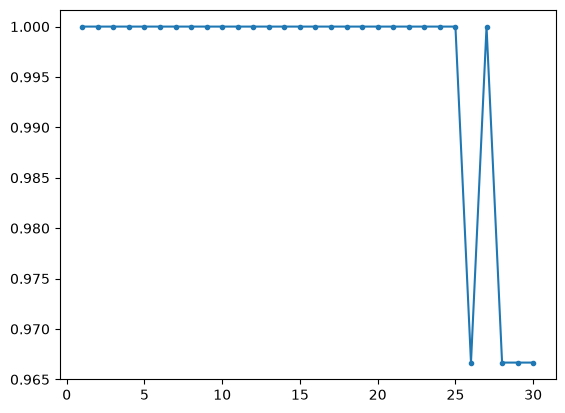

In [20]:
k_list = [i for i in range(1, 31)]
scores = []

for k in k_list:
    knn_classifier = KNeighborsClassifier(n_neighbors=k)
    knn_classifier.fit(X_train, y_train)

    preds = knn_classifier.predict(X_test)
    acc =  accuracy_score(y_test, preds)
    scores.append(acc)

plt.plot(k_list, scores, marker='.')
plt.show()

In [21]:
imdb = load_dataset("stanfordnlp/imdb")
imdb_train, imdb_test = imdb['train'], imdb['test']
len(imdb_train["text"]), len(imdb_test["text"])

(25000, 25000)

In [23]:
vectorizer = CountVectorizer(max_features=1000)
X_train = vectorizer.fit_transform(imdb_train['text'])
X_test = vectorizer.transform(imdb_test['text'])

y_train = np.array(imdb_train["label"])
y_test = np.array(imdb_test["label"])

In [24]:
scaler = StandardScaler(with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train, y_train)

y_pred = knn_classifier.predict(X_test)
print(accuracy_score(y_test, y_pred), f1_score(y_test, y_pred))

0.63428 0.6636005739725523
